__Markus Mulvihill__

__Last updated April 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
from matplotlib import rcParams

# Introduction

Within this file, different methods of parameter estimation will be implemented and compared to predict the Insulin Sensitivity $\, SI$ in patients

# Constant SI with State Augmentation

In [12]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_static_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_static_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_static_04.npy")
    all_vars = np.load("../scripts/variables/vars_augment_static_04.npy")
    states = np.load("../scripts/variables/states_augment_static_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment.py")

Loaded variables


In [13]:
FIG_WIDTH = 7.5  # width of figure in inches

TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=TINY_SIZE, titleweight="bold")  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=TINY_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False

In [14]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "04"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
dev_perc = cfg[curr_module]["dev_perc"]
deviations = cfg[curr_module]["deviations"]
num_deviations = len(deviations)

filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)

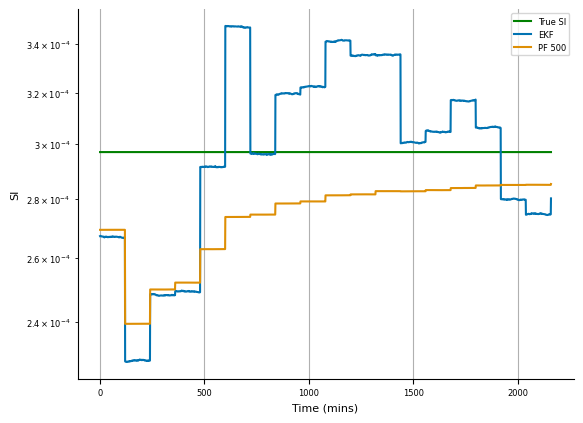

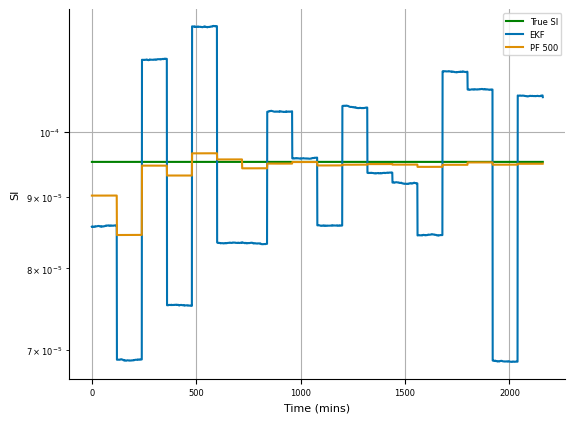

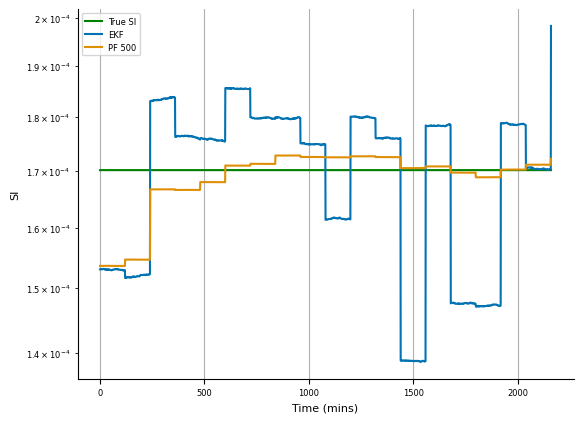

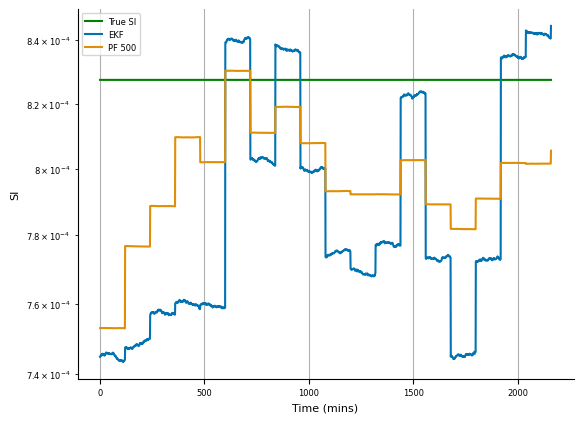

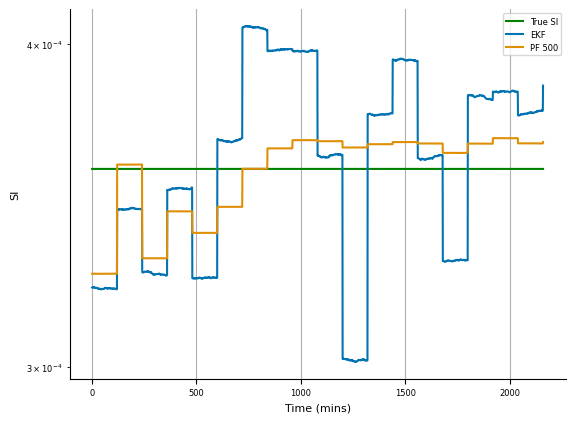

In [15]:
time = np.arange(SI_true_arr.shape[1])
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters)

for i in range(5):
    fig, ax = plt.subplots()
    true_SI = SI_true_arr[i, :]
    ax.semilogy(time, true_SI, color="green", label="True SI")
    for j in range(num_filters):
        patient = i
        deviation = 0
        est = SI_ests[deviation, j, i, :]
        std = np.sqrt(all_vars[deviation, j, i, :])
        ax.semilogy(time, est, linestyle="-", color=palette[j], label=f"{filters[j]}")
        # ax.plot(time, est + std, linestyle="--", color=palette[j])
        # ax.plot(time, est - std, linestyle="--", color=palette[j])

    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.grid()
    ax.legend()

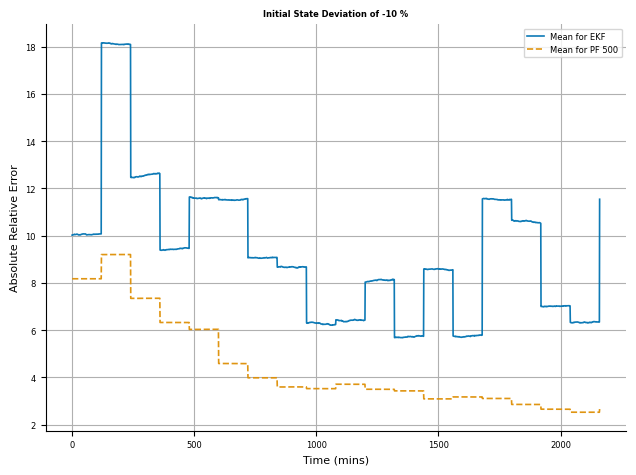

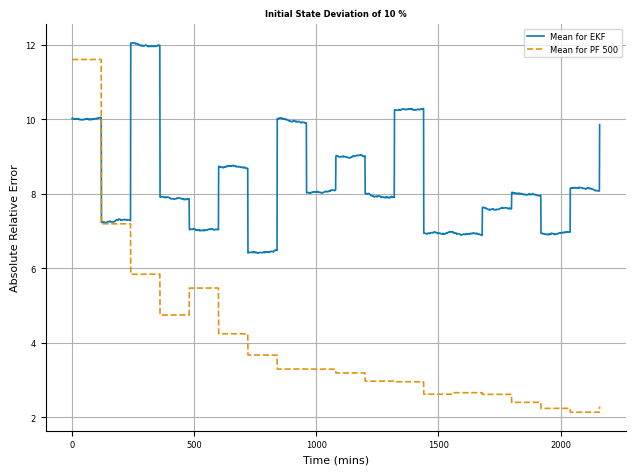

In [6]:
for j in range(num_deviations):
    mean_err = np.mean(SI_errs[j, :, :, :], axis=1)
    ci_low = np.percentile(SI_errs[j, :, :, :], low_perc, axis=1)
    ci_high = np.percentile(SI_errs[j, :, :, :], high_perc, axis=1)
    num_plots = len(filters)
    fig, ax = plt.subplots()

    for i in range(num_plots):
        ax.plot(
            time,
            mean_err[i],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean for {filters[i]}",
        )
        # ax.fill_between(
        #     time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18, label=f"{CI}% CI"
        # )
    ax.set_ylabel("Absolute Relative Error")
    ax.legend(loc="best")
    ax.set_xlabel("Time (mins)")
    ax.set_title(f"Initial State Deviation of {dev_perc[j]} %")
    ax.grid()
    fig.tight_layout()

# Changing SI with State Augmentation 

In [7]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_vary_04.npy")
    SI_vars = np.load("../scripts/variables/SI_vars_augment_vary_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_vary_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_vary_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment_vary.py")

Loaded variables


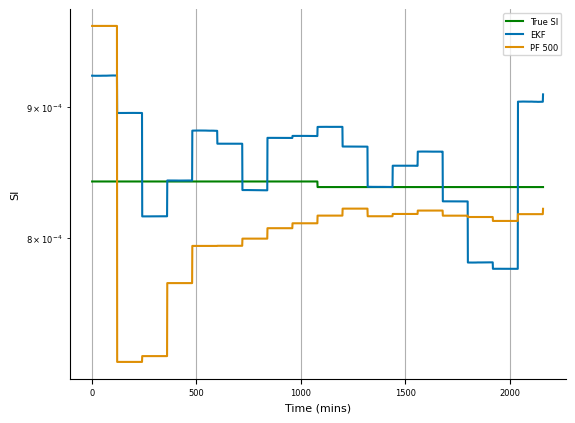

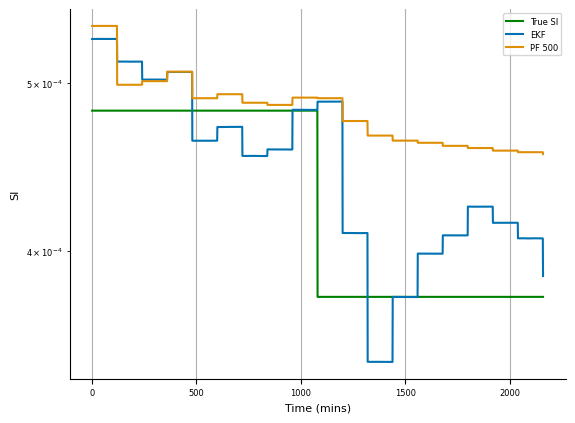

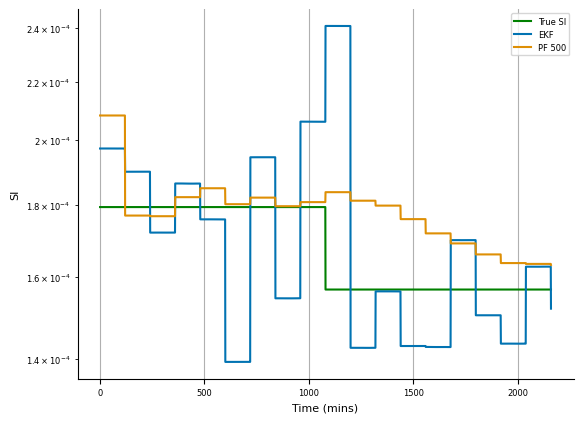

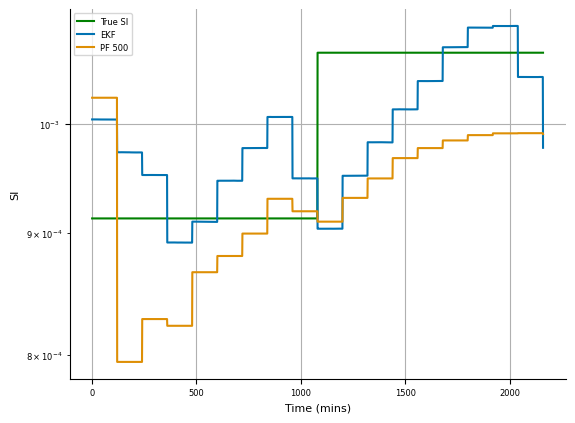

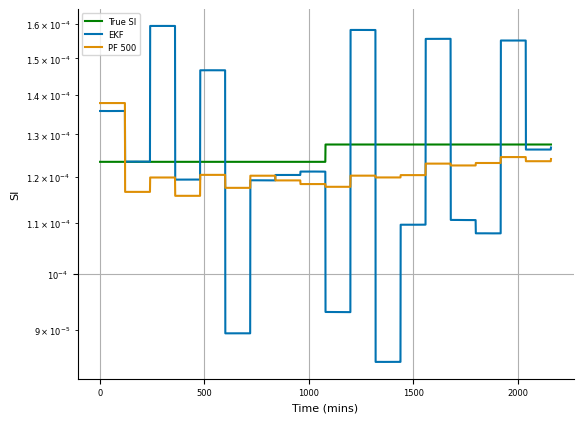

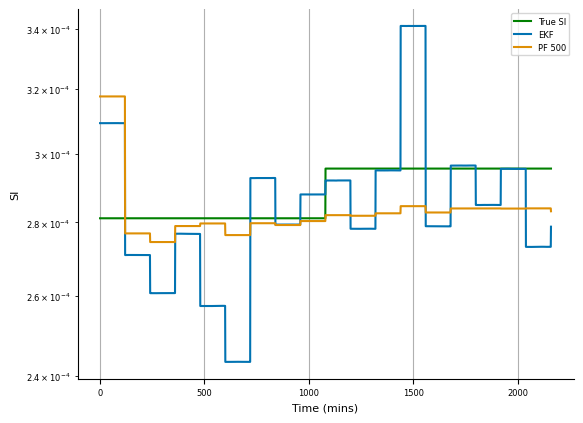

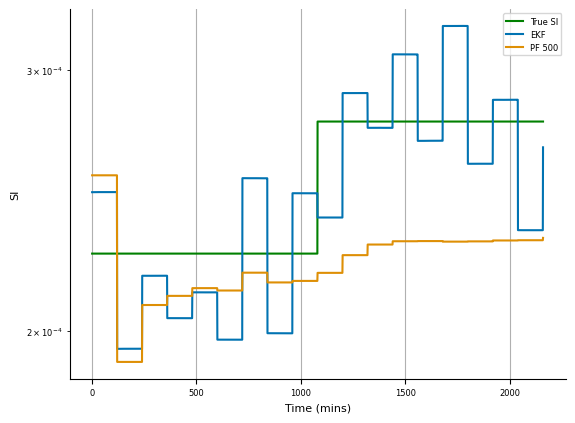

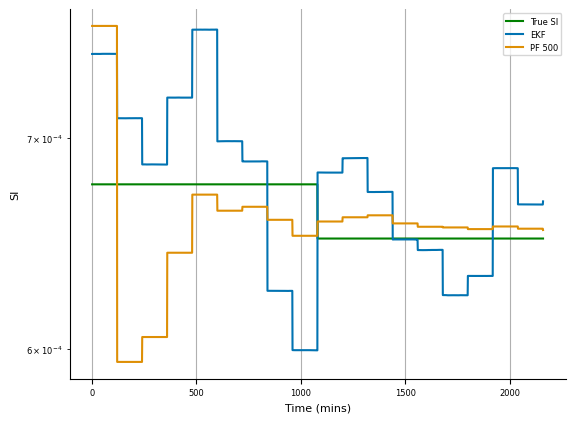

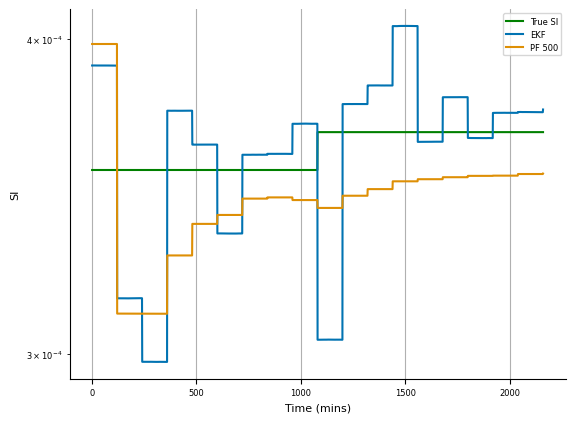

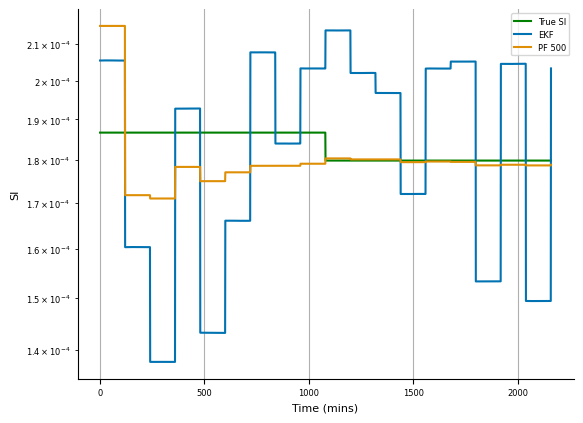

In [10]:
for i in range(SI_true_arr.shape[0]):
    patient = i
    deviation = 1
    fig, ax = plt.subplots()
    true_SI = SI_true_arr[patient, :]
    ax.semilogy(time, true_SI, color="green", label="True SI")
    for j in range(num_filters):
        est = SI_ests[deviation, j, patient, :]
        ax.semilogy(time, est, linestyle="-", color=palette[j], label=f"{filters[j]}")
    
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.grid()
    ax.legend()

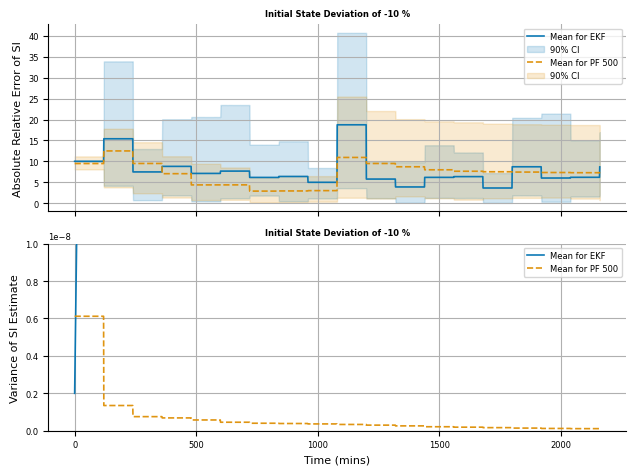

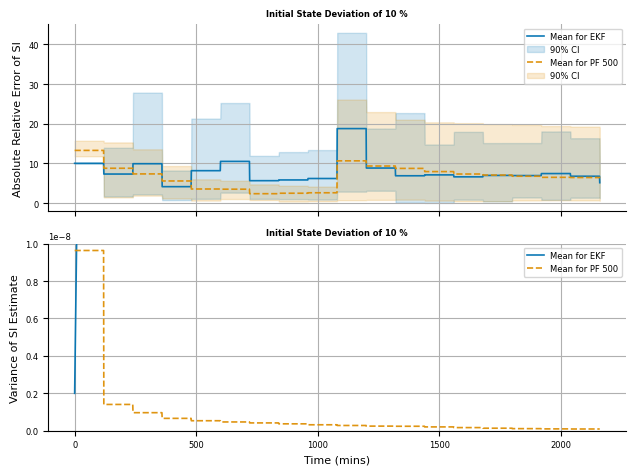

In [9]:
for j in range(num_deviations):
    mean_err = np.mean(SI_errs[j, :, :, :], axis=1)
    mean_var = np.abs(np.mean(SI_vars[j, :, :, :], axis=1))

    ci_low = np.percentile(SI_errs[j, :, :, :], low_perc, axis=1)
    ci_high = np.percentile(SI_errs[j, :, :, :], high_perc, axis=1)
    time = np.arange(mean_err.shape[1])
    num_plots = len(filters)
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters)

    fig, ax = plt.subplots(2, 1, sharex=True)

    for i in range(num_plots):
        ax[0].plot(
            time,
            mean_err[i],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean for {filters[i]}",
        )
        ax[0].fill_between(
            time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18, label=f"{CI}% CI"
        )
        ax[1].plot(
            time,
            mean_var[i],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean for {filters[i]}",
        )

    ax[0].set_ylabel("Absolute Relative Error of SI")
    ax[0].legend(loc="best")
    ax[0].set_title(f"Initial State Deviation of {dev_perc[j]} %")
    ax[0].grid()

    ax[1].set_ylabel("Variance of SI Estimate")
    ax[1].set_xlabel("Time (mins)")
    ax[1].legend(loc="best")
    ax[1].set_title(f"Initial State Deviation of {dev_perc[j]} %")
    ax[1].grid()
    ax[1].set_ylim([0, 1e-8])
    fig.tight_layout()